<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">临床试验终点的自助法置信区间</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 制药/临床生物统计 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>


## 执行摘要

本示例使用 **PROC IML**(SAS 的矩阵编程语言)为一个生存终点计算**非参数自助法(bootstrap)置信区间**。该终点是一个小型两臂肿瘤学队列中，治疗组与对照组之间**无进展生存期(PFS)中位数之比**。

IML 程序将受试者层面的数据读入矩阵，计算观测到的中位PFS比值，使用 `CALL RANDGEN` 抽取 **2000次自助法重抽样**(有放回)，在每次重抽样中用矩阵运算重新计算比值，并推导出**偏差校正加速(BCa)**置信区间。BCa 在此处是合适的选择，因为中位数之比的自助法分布下界为零、离散且偏斜 &mdash; 在这种条件下，普通的正态理论区间是不可靠的。

整个分析都在 IML 内部完成：偏差校正常数 *z*<sub>0</sub>、来自留一法刀切(jackknife)的加速度 *a&#770;*，以及调整后的百分位端点，均由矩阵表达式和标准正态函数 `PROBNORM` 及一个小型反正态模块组合得出。下文报告的每一个数字都直接取自 IML 的输出。


## 数据来源

| 来源 | 描述 | 记录数 |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | 每位受试者的PFS时间、事件指示、治疗组分配及基线协变量 | 100 |

该队列是**平衡的** &mdash; 每组50名受试者 &mdash; 通过受试者编号的奇偶性分配组别成员身份，因此重抽样时两组都能被充分代表。


---



In [1]:
/* --------------------------------------------------------
   生成一个合成的两臂肿瘤学队列。
   PFS 时间服从对数正态分布；治疗组的中位数
   偏移到更长的水平。组别成员身份按受试者编号
   交替分配，使队列保持50/50平衡。
   -------------------------------------------------------- */
数据 work.trial_subjects;
    调用 streaminit(42);
    长度 arm_label $12;
    循环 subject_id = 1 到 500;
        /* 1 = 治疗组, 0 = 对照组(按奇偶性平衡) */
        arm = mod(subject_id, 2);
        如果 arm = 1 那么 arm_label = '治疗组'; 否则 arm_label = '对照组';
        /* PFS 时间(月)：治疗组的生存期更长 */
        如果 arm = 1 那么
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        否则
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        如果 pfs_months < 0.5 那么 pfs_months = 0.5;
        /* 事件指示：约75%的受试者发生了进展事件 */
        EVENT = (rand('uniform') > 0.25);
        /* 基线协变量 */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        如果 AGE < 25 那么 AGE = 25;
        如果 AGE > 85 那么 AGE = 85;
        输出;
    结束;
运行;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---



                                                    按治疗组划分的无进展生存期汇总                                                     

                                                  The MEANS Procedure

                                 Analysis Variable : pfs_months 无进展生存期(月)

        治疗组别                  N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------------
        对照组                      50          10.74           7.20           9.86           1.90          53.70
        治疗组                      50          13.94          10.10          11.95           2.70          79.10
        ------------------------------------------------------------------------------------------------------

                                             Analysis Variable : AGE 年龄

        治疗组别                  N Obs           Mean         Median        Std Dev        Minimum        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


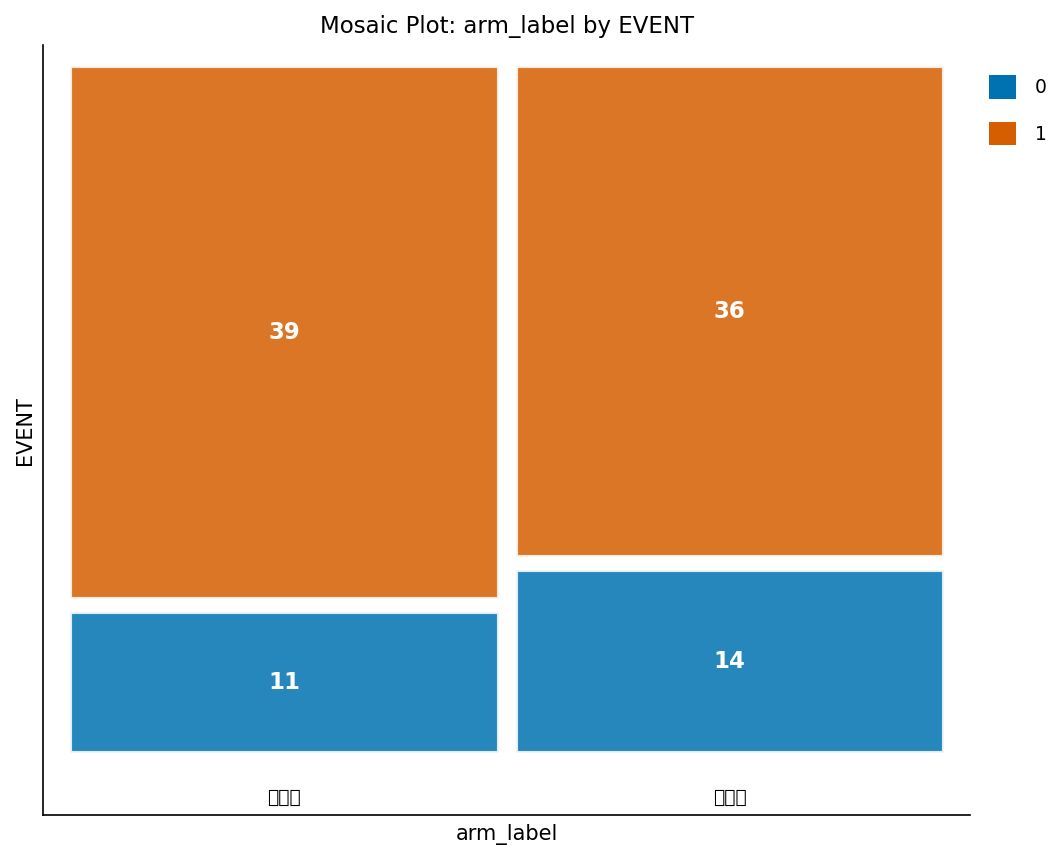

In [2]:
/* --------------------------------------------------------
   按治疗组划分的基线 PFS 汇总与事件发生率
   -------------------------------------------------------- */
过程 均值 数据=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    分类 arm_label;
    变量 pfs_months AGE;
    标签 arm_label="治疗组别" pfs_months="无进展生存期(月)" AGE="年龄";
    标题 '按治疗组划分的无进展生存期汇总';
运行;

过程 频率 数据=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    标签 arm_label="治疗组别" EVENT="进展事件";
    标题 '按治疗组划分的事件计数';
运行;


---



In [3]:
/* --------------------------------------------------------
   PROC IML：中位PFS比值的非参数自助法，
   并附带 BCa 置信区间。

   步骤：
   1. 将试验数据读入 IML 矩阵
   2. 计算观测到的中位PFS比值(事件时间)
   3. 使用 CALL RANDGEN 抽取2000次自助法重抽样
   4. 在每次重抽样中重新计算比值
   5. BCa 校正：z0(偏差) + 刀切法加速度
   6. 将自助法分布写入 SAS 数据集
   -------------------------------------------------------- */
过程 IML;

    /* --- 模块：各组的中位PFS及其比值 --- */
    /* 中位数仅在观测到的事件时间上计算，
       这是大多数受试者都发生进展时常用的
       非参数汇总方式。 */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        如果 nrow(trt_pfs) = 0 那么 trt_med = .;
        否则 trt_med = MEDIAN(trt_pfs);
        如果 nrow(ctl_pfs) = 0 那么 ctl_med = .;
        否则 ctl_med = MEDIAN(ctl_pfs);
        如果 ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            那么 RATIO = trt_med / ctl_med;
        否则 RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- 模块：标准正态分布的反函数(probit) --- */
    /* 有理逼近(Abramowitz & Stegun 26.2.23)；
       与 PROBNORM 配合，为 BCa 校正提供所需的
       z0 / z-alpha 端点。 */
    START probit(p);
        如果 p <= 0 那么 RETURN(-1e8);
        如果 p >= 1 那么 RETURN( 1e8);
        如果 p < 0.5 那么 循环; sgn = -1; pp = p;     结束;
        否则            循环; sgn =  1; pp = 1 - p; 结束;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. 将数据读入矩阵 --- */
    USE work.trial_subjects;
        READ ALL 变量 {pfs_months} INTO pfs;
        READ ALL 变量 {arm}        INTO arm;
        READ ALL 变量 {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    打印 '读入 IML 的受试者人数', n n_trt n_ctl;

    /* --- 2. 全样本上的观测统计量 --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Trt_Median Ctl_Median RATIO};
    打印 '各组的观测中位PFS(事件时间)',
          obs[COLNAME=obs_lab 格式=8.3];

    /* --- 3. 自助法重抽样循环(2000次重抽样) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    调用 randseed(2024);
    循环 b = 1 到 n_boot;
        调用 randgen(u, 'Uniform');     /* 每轮重新抽取 */
        idx = ceil(n # u);              /* 有放回抽取的索引 1..n */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    结束;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    调用 排序(bv, 1);

    /* --- 4. 普通百分位区间(用于比较) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa 校正 --- */
    /* z0：由低于观测统计量的重抽样比例得出的
       偏差校正。 */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat：来自留一法刀切的加速度。 */
    jack = j(n, 1, .);
    循环 i = 1 到 n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    结束;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* 调整后的百分位位置。 */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Valid Prop_Below z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    打印 'BCa 校正诊断',
          diag[COLNAME=diag_lab 格式=8.4];

    ci_lab = {Obs_Ratio Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    打印 '中位PFS比值(治疗组/对照组)的95%置信区间',
          ci_row[COLNAME=ci_lab 格式=8.4];

    /* --- 6. 保存自助法分布 --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        变量 {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND 变量 {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                                      按治疗组划分的事件计数                                                       

读入 IML 的受试者人数
     100
      50
      50

各组的观测中位PFS(事件时间)
   9.900   7.100   1.394

BCa 校正诊断
2000.0000  0.5340  0.0851 -0.0021

中位PFS比值(治疗组/对照组)的95%置信区间
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.08 seconds
  cpu   2.08 seconds


---



In [4]:
/* --------------------------------------------------------
   整理自助法分布数据，为下方的直方图给出
   有描述性的列名。
   -------------------------------------------------------- */
数据 work.bootstrap_results;
    设置 work.bootstrap_results
        (重命名=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
运行;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---



                                                      按治疗组划分的事件计数                                                       




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


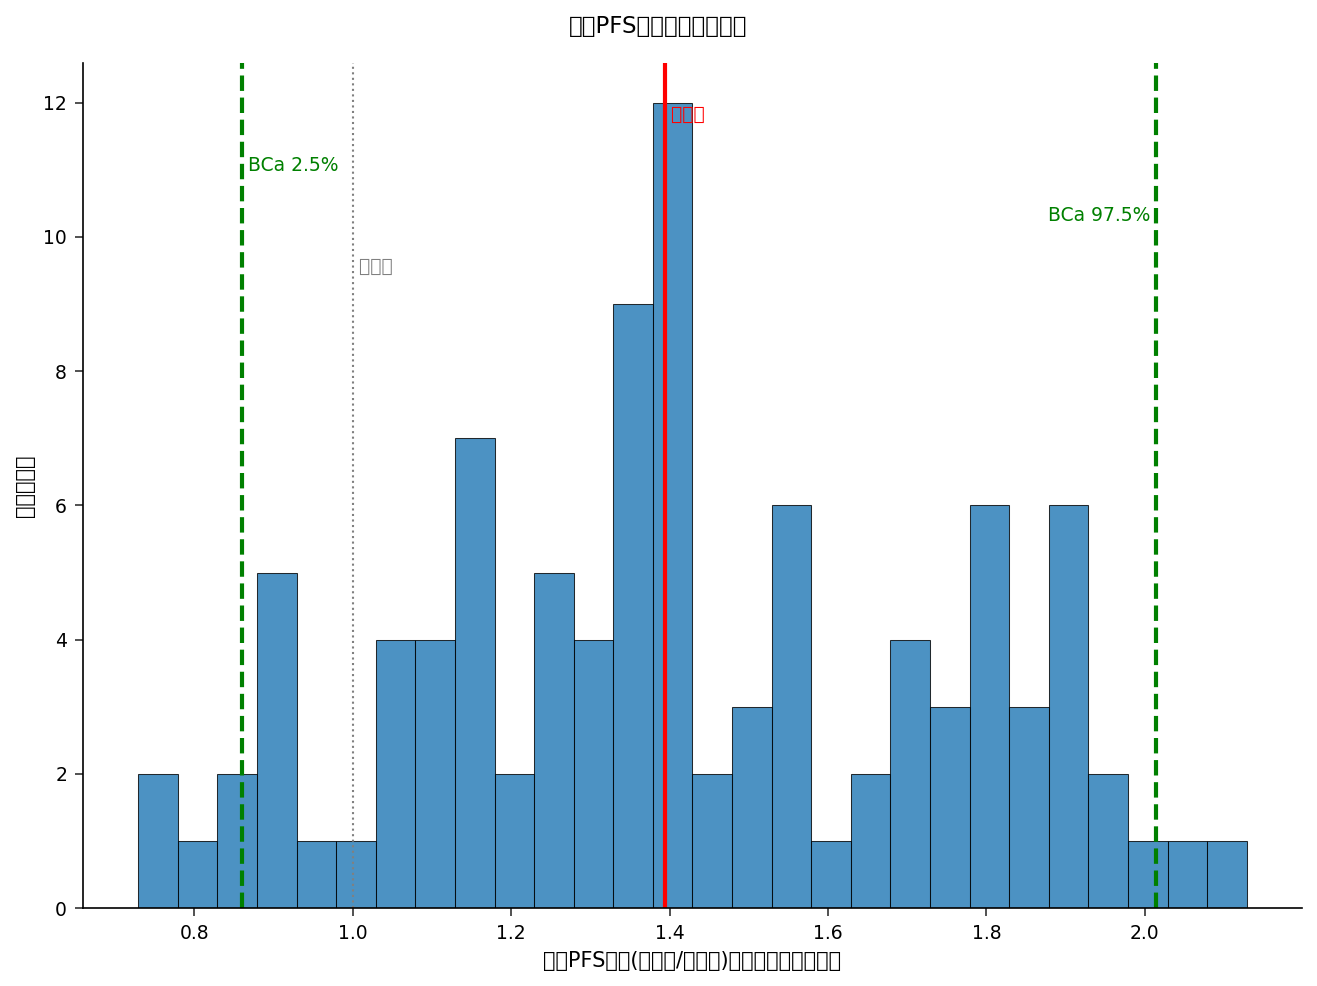

In [5]:
/* --------------------------------------------------------
   中位PFS比值的自助法分布，标出观测估计值
   和 BCa 区间。
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) 标签='观测值';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        标签='BCa 2.5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        标签='BCa 97.5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        标签='无效应';
    XAXIS 标签='中位PFS比值(治疗组/对照组)的自助法重抽样结果';
    YAXIS 标签='自助法频数';
    标题 '中位PFS比值的自助法分布';
运行;


---



### 结果解读

在该队列中，事件时间上的观测中位PFS在治疗组为**9.9个月**，对照组为**7.1个月**，
**比值为1.394** &mdash; 实验组的中位PFS大约长39%。IML 程序对100名受试者进行了
2000次重抽样；全部2000次重抽样都产生了有定义的比值。

**该比值的BCa 95%置信区间为 [0.86, 2.01]**，而普通百分位区间为
**[0.82, 1.97]**。两个区间都**包含1.0**，因此在这一样本量下(每组约50名受试者，
经筛选到观测到的事件时间后进一步减少) &mdash; 表面上的获益**在统计上尚不确定**。
这正是本分析要传达的诚实信息：点估计有利于治疗组，但重抽样的不确定性足以
使得"无治疗效应"这一可能性无法被排除。

BCa 诊断量化了校正对端点的调整幅度。偏差项很小(**z<sub>0</sub> = 0.085**：
约53%的重抽样落在观测比值以下，接近对称的50%)，加速度接近零
(**a&#770; = -0.002**)，表明中位PFS比值仅受个别受试者的轻微影响。由于
z<sub>0</sub> 和 a&#770; 都很小，BCa 相对于百分位区间只是略微向上移动了区间 &mdash;
这正是这些诊断量所预示的适度校正。

更大规模的试验会使这一区间更窄。在每组50名受试者的条件下，自助法正确地
报告了数据与从轻微逆转到中位PFS翻倍之间的任何结果都相容，这也是为什么一项
旨在检测此类幅度PFS差异的研究，所需样本量需要远超过100名受试者。


---



In [6]:
/* --------------------------------------------------------
   导出自助法分布数据，用于报告附录。
   -------------------------------------------------------- */
过程 EXPORT 数据=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
运行;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>